In [125]:
import numpy as np

#  ilk olarak Veri setini oku
data = np.genfromtxt('StudentsPerformance.csv', delimiter=',', dtype=str, skip_header=1)

# sonra kolon isimlerini kontrol etmek için ilk satırı ayrı okusun
with open('StudentsPerformance.csv', 'r') as f:
    headers = f.readline().strip().split(',')
print("Sutunlar:", headers)

# son olarak örnek birkaç satır göstersin
print("İlk 5 satır:")
print(data[:5])



Sutunlar: ['"gender"', '"race/ethnicity"', '"parental level of education"', '"lunch"', '"test preparation course"', '"math score"', '"reading score"', '"writing score"']
İlk 5 satır:
[['"female"' '"group B"' '"bachelor\'s degree"' '"standard"' '"none"'
  '"72"' '"72"' '"74"']
 ['"female"' '"group C"' '"some college"' '"standard"' '"completed"'
  '"69"' '"90"' '"88"']
 ['"female"' '"group B"' '"master\'s degree"' '"standard"' '"none"'
  '"90"' '"95"' '"93"']
 ['"male"' '"group A"' '"associate\'s degree"' '"free/reduced"' '"none"'
  '"47"' '"57"' '"44"']
 ['"male"' '"group C"' '"some college"' '"standard"' '"none"' '"76"'
  '"78"' '"75"']]


In [127]:
# --- 1. Sayısal sütunları ayıklayalım ---
# Verileri string olarak al
math_scores_str = data[:, 5]
reading_scores_str = data[:, 6]
writing_scores_str = data[:, 7]

# Tırnakları temizlemek için(veri seti string olmamalı)
math_scores_clean = np.char.strip(math_scores_str, '"')
reading_scores_clean = np.char.strip(reading_scores_str, '"')
writing_scores_clean = np.char.strip(writing_scores_str, '"')

# Şimdi float'a çevirelim
math_scores = math_scores_clean.astype(float)
reading_scores = reading_scores_clean.astype(float)
writing_scores = writing_scores_clean.astype(float)

# X matrisi: [1, reading_score(x1 yani), writing_score(x2)] y:tahmin etmek istediğimşz şey
X = np.column_stack((np.ones(len(math_scores)), reading_scores, writing_scores))

# y vektörü
y = math_scores

print("X matrisi (ilk 5 satır):")
print(X[:5])
print("\ny vektörü (ilk 5 değer):")
print(y[:5])


X matrisi (ilk 5 satır):
[[ 1. 72. 74.]
 [ 1. 90. 88.]
 [ 1. 95. 93.]
 [ 1. 57. 44.]
 [ 1. 78. 75.]]

y vektörü (ilk 5 değer):
[72. 69. 90. 47. 76.]


In [129]:
#  2. Çok değişkenli lineer regresyon katsayılarını hesapla ---
# Normal Equation: b = (X^T * X)^(-1) * X^T * y

# ilk olarak X'in transpozunu alalım
X_T = X.T

# sonra (X^T * X) hesaplasın
XTX = X_T @ X

# daha sonra TERSİni al
XTX_inv = np.linalg.inv(XTX)

# 4. olarak da (X^T * y)
XTy = X_T @ y

# son olarak Katsayılar(b0, b1, b2)  (@ : matris çarpımı operatörğ)
b = XTX_inv @ XTy

print("Katsayılar (b0, b1, b2):")
print(b)


Katsayılar (b0, b1, b2):
[7.52409205 0.60128965 0.24942405]


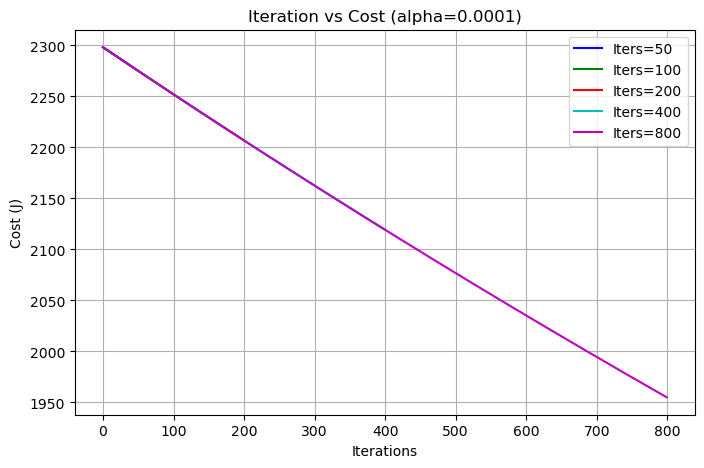

In [131]:
# Çok değişkenli Lineeer Regresyon için Gradiant Descent ve Normalizasyon işlemi

import numpy as np
import matplotlib.pyplot as plt

#  ilk olarak Z-score Normalizasyon Fonksiyonu
def feature_normalize_zscore(X_no_bias):
    mu = np.mean(X_no_bias, axis=0)      # Her sütunun ortalamasını alıyoruz
    sigma = np.std(X_no_bias, axis=0)    # Her sütunun standart sapmasını aldık
    Xn = (X_no_bias - mu) / sigma        # Bu Z-score formülü
    return Xn, mu, sigma


#  2. Cost yani MSE Hesaplama Fonksiyonu 
def compute_cost_multi(X, y, theta):
    m = len(y)
    err = X @ theta - y
    J = (err @ err) / (2 * m)
    return J


# 3. Gradient Descent fonksiyonu hesaplayım
def gradient_descent_multi(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    
    for i in range(num_iters):
        theta = theta - (alpha / m) * (X.T @ (X @ theta - y))  # Gradient descent güncellemesi
        J_history[i] = compute_cost_multi(X, y, theta)         # Her adımda cost değerini kaydetsin(öğrenme ilerliyor mu görmek için
    return theta, J_history


# 4. Özellikleri normalize et ama bias hariç (çünkü bias sutunu sabit 1'lerden oluşuyo.yoksa model çöker.)
X_feat = X[:, 1:]                              # Bias sütununu (1’leri) çıkar
Xn_feat, mu_z, sigma_z = feature_normalize_zscore(X_feat)  # Z-score uygula
Xn = np.column_stack((np.ones(len(y)), Xn_feat))  # Bias sütununu geri ekle


#  5. Gradient Descent ile theta değerlerini öğrenelim
alpha = 0.0001       # Öğrenme oranı bu olsun 
iter_list = [50, 100, 200, 400, 800]  # Farklı iterasyon sayıları
histories = {}

for iters in iter_list:
    theta0 = np.zeros(Xn.shape[1])              # Başlangıç theta [0,0,0]
    theta, J_hist = gradient_descent_multi(Xn, y, theta0, alpha, iters)
    histories[iters] = J_hist

# 6.  Cost (J) Grafiğini Çiz  
plt.figure(figsize=(8,5))
colors = ['b', 'g', 'r', 'c', 'm']  # her iterasyon farklı renkle göstersin

for i, iters in enumerate(iter_list):
    theta0 = np.zeros(Xn.shape[1])  # her iterasyon başında sıfırla
    theta, J_hist = gradient_descent_multi(Xn, y, theta0, alpha, iters)
    plt.plot(np.arange(len(J_hist)), J_hist, color=colors[i], label=f'Iters={iters}')

plt.xlabel('Iterations')
plt.ylabel('Cost (J)')
plt.title(f'Iteration vs Cost (alpha={alpha})')
plt.legend()
plt.grid(True)
plt.show()


In [132]:
#  7. Gradient Descent sonucunda elde edilen theta değerlerini yazdırsın
print("Gradient Descent ile bulunan katsayılar (θ0, θ1, θ2):")
print(theta)

#  8. Normal Equation sonucu ile karşılaştır
print("\nNormal Equation katsayıları (b0, b1, b2):")
print(b)

#  9. Farkı gözlemleyelim 
print("\nFark (GradientDescent - NormalEquation):")
print(theta - b)
#burda amacımız garient descent gerçekten doğru yöne gitmiş mi? 
#fark küçükse : model doğru öğenmiş
#fark büyükse: sorun var demektir


Gradient Descent ile bulunan katsayılar (θ0, θ1, θ2):
[5.08140783 0.91838965 0.90031149]

Normal Equation katsayıları (b0, b1, b2):
[7.52409205 0.60128965 0.24942405]

Fark (GradientDescent - NormalEquation):
[-2.44268422  0.3171      0.65088745]


In [135]:
#  GD katsayılarını orijinal ölçekteki katsayılara çevir
# Xn'i üretirken tuttuğumuz mu_z ve sigma_z kullanılacak (X_feat = X[:,1:] içindi)

theta_gd = theta.copy()  # GD sonucu
sigma = sigma_z
mu = mu_z

beta = np.zeros_like(theta_gd)   # orijinal ölçekteki katsayılar
beta[1:] = theta_gd[1:] / sigma  # beta_j = theta_j /  sigma_j 
beta[0]  = theta_gd[0] - np.sum(mu * (theta_gd[1:] / sigma))  # beta_0

print("GD -> Orijinal ölçekte katsayılar (beta0, beta1, beta2):")
print(beta)

print("\nNormal Equation katsayilari (b0, b1, b2):")
print(b)

print("\nFark (beta - b):")
print(beta - b)


GD -> Orijinal ölçekte katsayılar (beta0, beta1, beta2):
[-3.30575475  0.06293405  0.05927759]

Normal Equation katsayilari (b0, b1, b2):
[7.52409205 0.60128965 0.24942405]

Fark (beta - b):
[-10.8298468   -0.5383556   -0.19014646]


In [137]:
#  1) Küçük bir grid-search: (alpha, iterasyon) taraması
#     burda amacımız final cstu en küçük yapan çifti seçmek

alpha_list = [1e-4, 3e-4, 1e-3]        #3 farklı öğrenme oranı 
iter_list  = [400, 800, 1200, 2000, 4000]  # 5 farklı iterasyon

best = {"alpha": None, "iters": None, "J": np.inf, "theta": None}

for a in alpha_list:
    for it in iter_list:
        theta0 = np.zeros(Xn.shape[1])
        theta_tmp, J_hist_tmp = gradient_descent_multi(Xn, y, theta0, a, it)
        final_cost = J_hist_tmp[-1]
        # En küçük cost'u tut
        if final_cost < best["J"]:
            best = {"alpha": a, "iters": it, "J": final_cost, "theta": theta_tmp}

print("Seçilen en iyi ayarlar -> alpha:", best["alpha"], " iters:", best["iters"], "  final cost:", best["J"])

# Seçilen en iyi theta
theta_best = best["theta"]

#  2) GD katsayılarını orijinal ölçeğe çevir (beta) ve b ile karşılaştır
#    zaten mu_z ve sigma_z, X'i z-score normalizerken kaydetmiştik.

sigma = sigma_z
mu    = mu_z

beta_best = np.zeros_like(theta_best)
beta_best[1:] = theta_best[1:] / sigma
beta_best[0]  = theta_best[0] - np.sum(mu * (theta_best[1:] / sigma))

print("\nGD -> Orijinal ölçekte KATSAYILAR (beta0, beta1, beta2):")
print(beta_best)

print("\nNormal Equation katsayıları (b0, b1, b2):")
print(b)

print("\nFark (beta_best - b):")
print(beta_best - b)


Seçilen en iyi ayarlar -> alpha: 0.001  iters: 4000   final cost: 38.367437517752634

GD -> Orijinal ölçekte KATSAYILAR (beta0, beta1, beta2):
[6.87797609 0.45864469 0.38614905]

Normal Equation katsayıları (b0, b1, b2):
[7.52409205 0.60128965 0.24942405]

Fark (beta_best - b):
[-0.64611596 -0.14264496  0.136725  ]


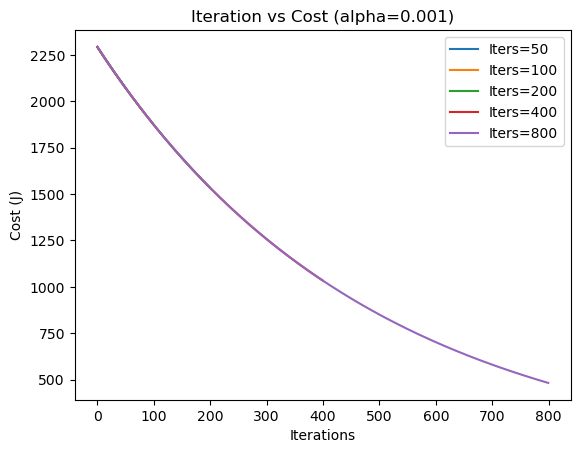

In [138]:
import matplotlib.pyplot as plt

best_alpha = best["alpha"]   # grid-search’ten geldi
iters_show = [50, 100, 200, 400, 800]  # istenen 5 iterayson öreneği

plt.figure()
for it in iters_show:
    theta0 = np.zeros(Xn.shape[1])
    _, J_hist = gradient_descent_multi(Xn, y, theta0, best_alpha, it)
    plt.plot(np.arange(it), J_hist, label=f'Iters={it}')
plt.xlabel('Iterations'); plt.ylabel('Cost (J)')
plt.title(f'Iteration vs Cost (alpha={best_alpha})')
plt.legend(); plt.show()


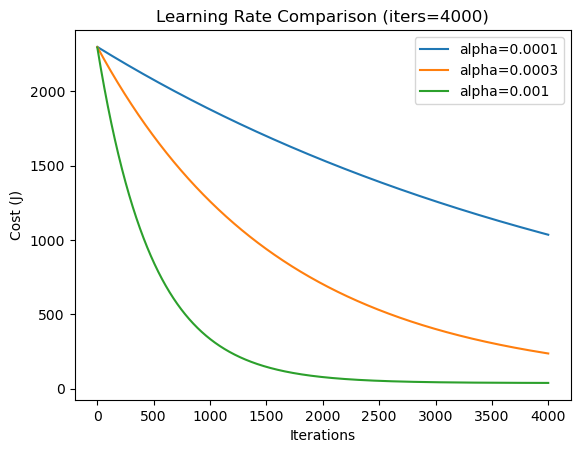

In [141]:
best_iters = best["iters"]          # grid-searchten gelen en iyi iterasyon
alphas_cmp = [1e-4, 3e-4, 1e-3]     # 3 farklı α

plt.figure()
for a in alphas_cmp:
    theta0 = np.zeros(Xn.shape[1])
    _, J_hist = gradient_descent_multi(Xn, y, theta0, a, best_iters)
    plt.plot(np.arange(best_iters), J_hist, label=f'alpha={a}')
plt.xlabel('Iterations'); plt.ylabel('Cost (J)')
plt.title(f'Learning Rate Comparison (iters={best_iters})')
plt.legend(); plt.show()


In [143]:
#  Min-Max Normalizasyonu (bias hariç özellikler için) 
def feature_normalize_minmax(X_no_bias):
    # X_no_bias:  bias sütunu olmayan özellik matrisi (n x p)
    xmin = np.min(X_no_bias, axis=0)
    xmax = np.max(X_no_bias, axis=0)
    # Sıfır bölme güvenliği: aralık 0 ise 1 yapsın.
    rng = np.where((xmax - xmin) == 0, 1, (xmax - xmin))
    Xn = (X_no_bias - xmin) / rng
    return Xn, xmin, xmax


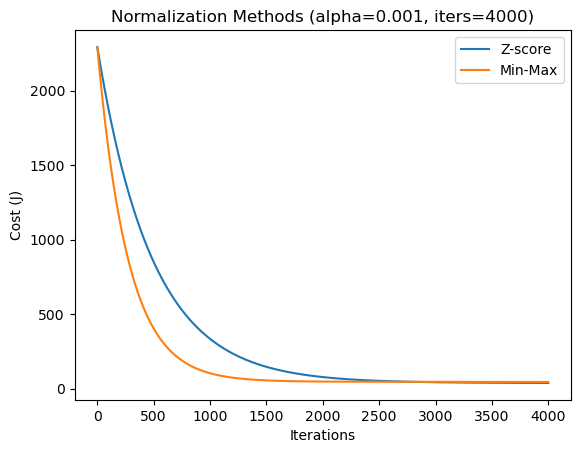

In [145]:
# 5. ADIM: İki normalizasyon yöntemiyle karşılaştırma 

# 1) En iyi hiperparamtreleri al 
alpha_fixed = best["alpha"]
iters_fixed = best["iters"]

# 2) Z-score için: zaten daha önce oluşturduğumuz Xn mevcut (bias dahil: [1 | zscore(features)])
#    Bu veriyle eğitsin  ve cost geçmişini alsın
theta0 = np.zeros(Xn.shape[1])
theta_z, Jz = gradient_descent_multi(Xn, y, theta0, alpha_fixed, iters_fixed)

# 3) Min-Max için: sadece özellikleri normalize et, sonra bias eklensin 
Xmm_feat, xmin, xmax = feature_normalize_minmax(X[:, 1:])   # [reading, writing]
Xmm = np.column_stack((np.ones(len(y)), Xmm_feat))          # [1 | minmax(features)]

theta0 = np.zeros(Xmm.shape[1])
theta_m, Jm = gradient_descent_multi(Xmm, y, theta0, alpha_fixed, iters_fixed)

# 4) şimdi grafiği çiz (x:iterasyon z:cost olmak üzere)
plt.figure()
plt.plot(np.arange(iters_fixed), Jz, label='Z-score')
plt.plot(np.arange(iters_fixed), Jm, label='Min-Max')
plt.xlabel('Iterations')
plt.ylabel('Cost (J)')
plt.title(f'Normalization Methods (alpha={alpha_fixed}, iters={iters_fixed})')
plt.legend()
plt.show()


In [147]:
#  Öğrenci notu tahmini (reading, writing -> math) ---
def predict_math_score(reading, writing, mu, sigma, theta):
    x = np.array([reading, writing], dtype=float)
    x_norm = (x - mu) / sigma          # Z-score normalizasyonu
    x_with_bias = np.insert(x_norm, 0, 1.0)
    return float(x_with_bias @ theta)

# Örnek özellikler (reading ve writing skorları)
predicted_math = predict_math_score(88, 92, mu_z, sigma_z, theta_best)

print(f"reading=88, writing=92 için tahmini math score: {predicted_math:.2f}, beklenir.")

reading=88, writing=92 için tahmini math score: 82.76, beklenir.
